In [ ]:
#Code for making figures in Fig 2 of DOI manuscript

In [1]:
#Importing Important Stuff
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics as stat 
import math 
from pylab import *
import os
import fmEphys as fme
from tqdm import tqdm
import seaborn as sns
from sklearn.neighbors import KernelDensity

import sys
sys.path.append(r"C:\Users\Niell Lab\Documents\GitHub\freely-moving-saccades")
import saccadeAnalysis as sacc


def norm_psth(psth_pre, psth_post):
    kernel_size = 25
    kernel = np.ones(kernel_size) / kernel_size

    #psth_pre = np.convolve(psth_pre, kernel, mode='same')
    #psth_post = np.convolve(psth_post, kernel, mode='same')
    
    #subtract off baseline value
    baselined_psth_pre = psth_pre - np.nanmean(psth_pre[200:800].astype(float))
    baselined_psth_post = psth_post - np.nanmean(psth_post[200:800].astype(float))

    #find max FR before and after injection
    mx_pre = np.nanmax(np.abs(baselined_psth_pre[750:1500]))
    mx_post = np.nanmax(np.abs(baselined_psth_post[750:1500]))
    Mx = np.nanmax([mx_pre,mx_post])

    #normalize psth to max
    norm_psth_pre = baselined_psth_pre/Mx
    norm_psth_post = baselined_psth_post/Mx

    return norm_psth_pre, norm_psth_post 

def calc_PSTH(spikeT, eventT, bandwidth=10, resample_size=1, edgedrop=15, win=1000, num_events=None):
    """
    calcualtes for a single cell at a time

    bandwidth (in msec)
    resample_size (msec)
    edgedrop (msec to drop at the start and end of the window so eliminate artifacts of filtering)
    win = 1000msec before and after
    """

    # Some conversions
    bandwidth = bandwidth / 1000
    resample_size = resample_size / 1000
    win = win / 1000
    edgedrop = edgedrop / 1000
    edgedrop_ind = int(edgedrop / resample_size)

    # Setup time bins. The bins of the returned PSTH will be -`win` msec to +`win` msec
    # with `resame_size` msec bins, where 0 is the time of the event. Because of edge effects
    # from the gaussian filter, we'll calculate the PSTH with an extra `edgedrop` msec at the
    # start and end so that the edges of the PSTH can be dropped without losing timepoints
    # we care about.
    bins = np.arange(-win-edgedrop, win+edgedrop+resample_size, resample_size)

    # if there is only one event time (i.e. if it's an int for all spikes like eventT=np.array(0)
    if np.size(eventT)>1:

        # Get the timestamps of spikes relative to events in `eventT`
        sps = []
        for i, t in enumerate(eventT):
            sp = spikeT-t
            # Only keep spikes in this window
            sp = sp[(sp <= (win+edgedrop)) & (sp >= (-win-edgedrop))]
            sps.extend(sp)
        num_events = np.size(eventT)
    else:
        sps = eventT.copy().flatten()
    
    # If `win` is 1000 msec, values in `sps` will fall between -1 and 1, since only spikes
    # that fall before or after the event by 1 second are included.
    # (Because of `edge_drop`, values can be a bit beyond `win` but those will be eliminated before
    # the PSTH is returned.
    sps = np.array(sps)

    # Calculate the PSTH using Kernel Density Estimation
    kernel = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(sps[:, np.newaxis])
    density = kernel.score_samples(bins[:, np.newaxis])

    # Here, `density` is a probability function that sums to 1. We want it in sp/sec.
    # We need to multiply by the # spikes to get the spike count per point. Then,
    # we divide by the number of events so that we get teh rate per event.
    psth = np.exp(density) * (np.size(sps) / num_events)

    # Drop the extra time at the start and end of the window, since it will have
    # edge effects from the gaussian filter. After dropping this, it will be the
    # size set by `win`, so no important timepoints are actually lost here.
    psth = psth[edgedrop_ind:-edgedrop_ind]

    return psth


def jitter(c, sz, maxdist=0.25):
    """ Jitter x values.

    This is useful for scatter plots of categorical data,
    when the distribution along y is more clear when the
    x position of that category is jittered slightly.

    Parameters
    ----------
    c : int or float
        Center position of the data.
    sz : int
        Number of data points.
    maxdist : float
        Maximum distance that a value can be jittered
        from their center point, `c`.

    Returns
    -------
    j_x : np.array
        Jittered x values in a 1D array of length `sz`.

    """

    j_x = np.ones(sz) + np.random.uniform(c-maxdist, c+maxdist, sz)

    return j_x

def plot_group_mean_std(group_mean, group_std, color, label):
    plt.plot(group_mean, c=color, label=label, linewidth=2)
    plt.fill_between(range(len(group_mean)), group_mean - group_std, group_mean + group_std, color=color, alpha=0.25)
    #plt.legend()

Loading DLC 2.3.0...


In [2]:
figpath = 'G:\My Drive\Science Files\Manuscripts\DOI Project\Figures\Fig 2 - DOI suppresses gaze shift responses'

In [3]:
DOI_Data = pd.read_hdf(r"D:\PrePostDOI\DOI Datasets\AllMice_GazeShifts_DOI.h5")
Saline_Data = pd.read_hdf(r"D:\PrePostDOI\Saline Datasets\AllMice_GazeShift_Saline.h5")

DOI_Data_4Mice_Light = pd.read_hdf(r"D:\PrePostDOI\DOI Datasets\LD_Mice_Light_GazeShifts_DOI.h5")
DOI_Data_4Mice_Dark = pd.read_hdf(r"D:\PrePostDOI\DOI Datasets\LD_Mice_Dark_GazeShifts_DOI.h5")

In [174]:
DOI_Data_temp = DOI_Data.copy()

In [182]:
DOI_Data_temp =DOI_Data_temp.drop(columns=['Waveform',
       'Waveform_Cluster', 'Wn_depth_from_layer5', 'SU_Channel', 'SU_Shank',
       'Contamination_Index', 'FmLt_depth'])

In [184]:
DOI_Data_12Mice = pd.concat([DOI_Data_temp, DOI_Data_4Mice_Light])

In [223]:
print(np.shape(DOI_Data))
print(np.shape(DOI_Data_4Mice_Light))
print(np.shape(DOI_Data_12Mice))

(418, 27)
(192, 21)
(610, 21)


In [4]:
DOI_NotContaminted = np.where(DOI_Data.loc[:,'Contamination_Index']<=30)
Saline_NotContaminted = np.where(Saline_Data.loc[:,'Contamination_Idx']<=30)

DOI_Data = DOI_Data.iloc[DOI_NotContaminted]
Saline_Data = Saline_Data.iloc[Saline_NotContaminted]
print(len(DOI_Data))
print(len(Saline_Data))

Mouse = np.stack(DOI_Data.loc[:,'Mouse'])
print(len(np.unique(Mouse)))


DOI_NotContaminted_12Mice = np.where(DOI_Data_12Mice.loc[:,'Contamination_Index']<=30)
DOI_Data_4Mice_Light = DOI_Data_12Mice.iloc[DOI_NotContaminted_12Mice]
DOI_Data_4Mice_Dark = DOI_Data_12Mice.iloc[DOI_NotContaminted_12Mice]
print(len(DOI_Data_12Mice))

418
148
9


NameError: name 'DOI_Data_12Mice' is not defined

In [5]:
Mouse = np.stack(DOI_Data.loc[:,'Mouse'])

Pre_DOI_Responsive = np.stack(DOI_Data.loc[:,'Pre_Responsive'])
Post_DOI_Responsive = np.stack(DOI_Data.loc[:,'Post_Responsive'])

DOI_ResponsivetoBoth = Pre_DOI_Responsive + Post_DOI_Responsive
DOI_ResponsivetoBoth[DOI_ResponsivetoBoth<2] = 0
DOI_ResponsivetoBoth[DOI_ResponsivetoBoth==2] = 1

DOI_ResponsivetoOne = Pre_DOI_Responsive + Post_DOI_Responsive
DOI_ResponsivetoOne[DOI_ResponsivetoOne>0] = 1
DOI_ResponsivetoOne = DOI_ResponsivetoOne.astype(bool)

Pre_Saline_Responsive = np.stack(Saline_Data.loc[:,'Pre_Responsive'])
Post_Saline_Responsive = np.stack(Saline_Data.loc[:,'Post_Responsive'])

Saline_ResponsivetoBoth = Pre_Saline_Responsive + Post_Saline_Responsive
Saline_ResponsivetoBoth[Saline_ResponsivetoBoth<2] = 0
Saline_ResponsivetoBoth[Saline_ResponsivetoBoth==2] = 1

Saline_ResponsivetoOne = Pre_Saline_Responsive + Post_Saline_Responsive
Saline_ResponsivetoOne[Saline_ResponsivetoOne>0] = 1
Saline_ResponsivetoOne = Saline_ResponsivetoOne.astype(bool)
#####################

Pre_DOI_Gaze = np.stack(DOI_Data.loc[:,'Pre_Pref_Gaze'])
Post_DOI_Gaze = np.stack(DOI_Data.loc[:,'Post_Pref_Gaze'])

Pre_Saline_Gaze = np.stack(Saline_Data.loc[:,'Pre_Pref_Gaze'])
Post_Saline_Gaze = np.stack(Saline_Data.loc[:,'Post_Pref_Gaze'])

Pre_DOI_SpikeNum = np.zeros(len(DOI_Data))
Post_DOI_SpikeNum = np.zeros(len(DOI_Data))

for ii in range(0, len(DOI_Data)):

    Pre_DOI_SpikeNum[ii] = len(DOI_Data.loc[DOI_Data.index[ii],'Pre_SpikeT']) 
    Post_DOI_SpikeNum[ii] = len(DOI_Data.loc[DOI_Data.index[ii],'Post_SpikeT']) 

In [6]:
Mice = np.stack(DOI_Data.loc[Pre_DOI_Responsive.astype(bool),'Mouse'])
Mouse = np.unique(Mice)

Pre_DOI_Responsive_MouseAvs =  np.zeros(len(Mouse))
Post_DOI_Responsive_MouseAvs =  np.zeros(len(Mouse))
BothDOI_Responsive_MouseAvs =  np.zeros(len(Mouse))
DOI_NumCells =  np.zeros(len(Mouse))


for ii in range(0,len(Mouse)):
    Mouse_Idxes = np.argwhere(Mice == Mouse[ii])
    DOI_NumCells[ii] = len(Mouse_Idxes)
    Pre_DOI_Responsive_MouseAvs[ii] = np.nansum(Pre_DOI_Responsive[Mouse_Idxes])/len(Pre_DOI_Responsive[Mouse_Idxes])
    Post_DOI_Responsive_MouseAvs[ii] = np.nansum(Post_DOI_Responsive[Mouse_Idxes])/len(Post_DOI_Responsive[Mouse_Idxes])
    BothDOI_Responsive_MouseAvs[ii] = np.nansum(Pre_DOI_Responsive[Mouse_Idxes])/len(Pre_DOI_Responsive[Mouse_Idxes])
    
Saline_Mice = np.stack(Saline_Data.loc[Saline_ResponsivetoBoth.astype(bool),'Mouse'])
Saline_Mouse = np.unique(Saline_Mice)

Pre_Saline_Responsive_MouseAvs =  np.zeros(len(Saline_Mouse))
Post_Saline_Responsive_MouseAvs =  np.zeros(len(Saline_Mouse))
BothSaline_Responsive_MouseAvs =  np.zeros(len(Saline_Mouse))
Saline_NumCells =  np.zeros(len(Saline_Mouse))

for ii in range(0,len(Saline_Mouse)):
    Saline_Mouse_Idxes = np.argwhere(Saline_Mice == Saline_Mouse[ii])
    Saline_NumCells[ii] = len(Saline_Mouse_Idxes)
    Pre_Saline_Responsive_MouseAvs[ii] = np.nansum(Pre_Saline_Responsive[Saline_Mouse_Idxes])/len(Pre_Saline_Responsive[Saline_Mouse_Idxes])
    Post_Saline_Responsive_MouseAvs[ii] = np.nansum(Post_Saline_Responsive[Saline_Mouse_Idxes])/len(Post_Saline_Responsive[Saline_Mouse_Idxes])
    BothSaline_Responsive_MouseAvs[ii] = np.nansum(Saline_ResponsivetoBoth[Saline_Mouse_Idxes])/len(Saline_ResponsivetoBoth[Saline_Mouse_Idxes])

DOI_NumCell_Ratio = DOI_NumCells/np.nansum(DOI_NumCells)
Saline_NumCell_Ratio = Saline_NumCells/np.nansum(Saline_NumCells)


In [222]:
Mice = np.stack(DOI_Data.loc[:,'Mouse'])
Mouse = np.unique(Mice)
Mouse

array(['012324_G6CK11BTT', '022024_G6CK10DTT', '072624_J708LT',
       '080224_J705RT', '081024_J720LT', '091223_G6CK9GRT',
       '092223_G6CK9GTT', '110723_J683LT', '122024_J728LT'], dtype='<U16')

In [14]:
print('Pre DOI')
print(np.nanmean(Pre_DOI_Responsive_MouseAvs))
print(np.nanstd(Pre_DOI_Responsive_MouseAvs)/sqrt(len(Pre_DOI_Responsive_MouseAvs)))
print('Post DOI')
print(np.nanmean(Post_DOI_Responsive_MouseAvs))
print(np.nanstd(Post_DOI_Responsive_MouseAvs)/sqrt(len(Post_DOI_Responsive_MouseAvs)))
print('Pre Saline')
print(np.nanmean(Pre_Saline_Responsive_MouseAvs))
print(np.nanstd(Pre_Saline_Responsive_MouseAvs)/sqrt(len(Pre_Saline_Responsive_MouseAvs)))
print('Pre Saline')
print(np.nanmean(Post_Saline_Responsive_MouseAvs))
print(np.nanstd(Post_Saline_Responsive_MouseAvs)/sqrt(len(Post_Saline_Responsive_MouseAvs)))

Pre DOI
0.8331509536569823
0.02097202397816379
Post DOI
0.7193805790737344
0.021840620501857835
Pre Saline
0.88567929150179
0.0508895440284744
Pre Saline
0.8228094968908988
0.061336501542845166


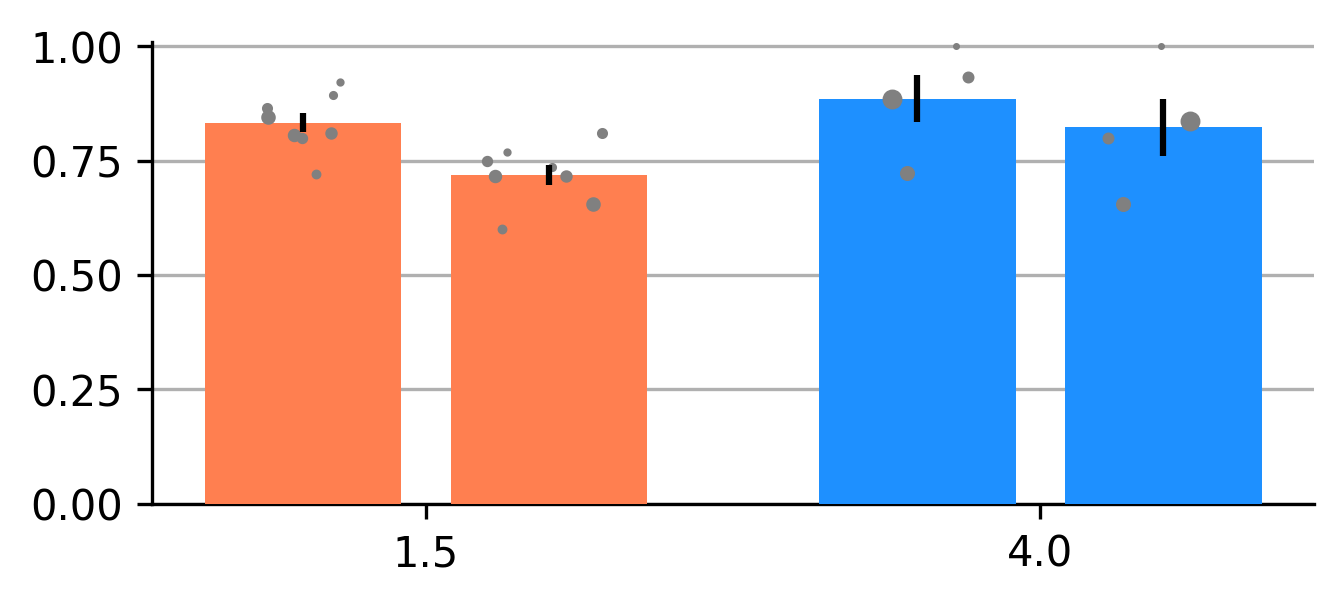

In [238]:
fig, axs=plt.subplots(1,1,figsize=(5,2), dpi=300)

plt.bar(1,np.nanmean(Pre_DOI_Responsive_MouseAvs),color = 'coral',zorder = 3,label= 'DOI')
plt.bar(3.5,np.nanmean(Pre_Saline_Responsive_MouseAvs),color = 'dodgerblue',zorder = 3,label = 'Saline')
plt.bar(2,np.nanmean(Post_DOI_Responsive_MouseAvs),color = 'coral',zorder = 3)
plt.bar(4.5,np.nanmean(Post_Saline_Responsive_MouseAvs),color = 'dodgerblue',zorder = 3)
#plt.bar(6,np.nanmean(BothDOI_Responsive_MouseAvs),color = 'coral',zorder = 3)
#plt.bar(7,np.nanmean(BothSaline_Responsive_MouseAvs),color = 'dodgerblue',zorder = 3)

for ii in range(0,8):
    plt.scatter(jitter(0,1), Pre_DOI_Responsive_MouseAvs[ii], color = 'grey', zorder = 4, label= 'DOI', s=25*DOI_NumCell_Ratio[ii])
    plt.scatter(jitter(1,1), Post_DOI_Responsive_MouseAvs[ii], color = 'grey', zorder = 4, label= 'DOI', s=25*DOI_NumCell_Ratio[ii])

for ii in range(0,4):
    plt.scatter(jitter(2.5,1), Pre_Saline_Responsive_MouseAvs[ii], color = 'grey', zorder = 4, label= 'DOI', s=25*Saline_NumCell_Ratio[ii])
    plt.scatter(jitter(3.5,1), Post_Saline_Responsive_MouseAvs[ii], color = 'grey', zorder = 4, label= 'DOI', s=25*Saline_NumCell_Ratio[ii])

#plt.scatter(jitter(0,len(Pre_DOI_Responsive_MouseAvs)),Pre_DOI_Responsive_MouseAvs,color = 'grey',zorder = 4,label= 'DOI',s=2)
#plt.scatter(jitter(1,len(Pre_Saline_Responsive_MouseAvs)),Pre_Saline_Responsive_MouseAvs,color = 'grey',zorder = 4,label = 'Saline',s=2)
#plt.scatter(jitter(2.5,len(Post_DOI_Responsive_MouseAvs)),Post_DOI_Responsive_MouseAvs,color = 'grey',zorder = 4,s=2)
#plt.scatter(jitter(3.5,len(Post_Saline_Responsive_MouseAvs)),Post_Saline_Responsive_MouseAvs,color = 'grey',zorder = 4,s=2)


plt.errorbar(1,np.nanmean(Pre_DOI_Responsive_MouseAvs),np.nanstd(Pre_DOI_Responsive_MouseAvs)/sqrt(len(Pre_DOI_Responsive_MouseAvs)),color='black',zorder = 5)
plt.errorbar(3.5,np.nanmean(Pre_Saline_Responsive_MouseAvs),np.nanstd(Pre_Saline_Responsive_MouseAvs)/sqrt(len(Pre_Saline_Responsive_MouseAvs)),color='black',zorder = 5)
plt.errorbar(2,np.nanmean(Post_DOI_Responsive_MouseAvs),np.nanstd(Post_DOI_Responsive_MouseAvs)/sqrt(len(Post_DOI_Responsive_MouseAvs)),color='black',zorder = 5)
plt.errorbar(4.5,np.nanmean(Post_Saline_Responsive_MouseAvs),np.nanstd(Post_Saline_Responsive_MouseAvs)/sqrt(len(Post_Saline_Responsive_MouseAvs)),color='black',zorder = 5)
#plt.errorbar(6,np.nanmean(BothDOI_Responsive_MouseAvs),np.nanstd(BothDOI_Responsive_MouseAvs)/sqrt(len(BothDOI_Responsive_MouseAvs)),color='black',zorder = 5)
#plt.errorbar(7,np.nanmean(BothSaline_Responsive_MouseAvs),np.nanstd(BothSaline_Responsive_MouseAvs)/sqrt(len(BothSaline_Responsive_MouseAvs)),color='black',zorder = 5)

plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

plt.xticks(ticks=[1.5,4])
plt.ylim(0,1.01)
plt.yticks(ticks = [0,.25,.5,.75,1])
plt.grid(axis='y',zorder =3)

fig.savefig(os.path.join(figpath, 'Percent Popln Responsive Bar Plot - With Mouse Avs.eps'), dpi=300)

In [17]:
import scipy
scipy.stats.ranksums(Pre_Saline_Responsive_MouseAvs,Post_Saline_Responsive_MouseAvs,alternative='greater')

RanksumsResult(statistic=0.7216878364870323, pvalue=0.23524321102939483)

In [18]:
scipy.stats.ranksums(Pre_DOI_Responsive_MouseAvs,Post_DOI_Responsive_MouseAvs,alternative='greater')

RanksumsResult(statistic=2.730546163854619, pvalue=0.0031614738479054665)

In [19]:
#Plotting Average Gaze shift response before and after drug administration
Pre_DOI_Gaze_Normed = np.zeros([np.shape(Pre_DOI_Gaze)[0],np.shape(Pre_DOI_Gaze)[1]])
Post_DOI_Gaze_Normed = np.zeros([np.shape(Pre_DOI_Gaze)[0],np.shape(Pre_DOI_Gaze)[1]])

for ii in range(0, len(Pre_DOI_Gaze)):
    Pre_DOI_Gaze_Normed[ii], Post_DOI_Gaze_Normed[ii] = norm_psth(Pre_DOI_Gaze[ii,:],Post_DOI_Gaze[ii,:])


    #Plotting Average Gaze shift response before and after drug administration
Pre_Saline_Gaze_Normed = np.zeros([np.shape(Pre_Saline_Gaze)[0],np.shape(Pre_Saline_Gaze)[1]])
Post_Saline_Gaze_Normed = np.zeros([np.shape(Pre_Saline_Gaze)[0],np.shape(Pre_Saline_Gaze)[1]])

for ii in range(0, len(Pre_Saline_Gaze)):
    Pre_Saline_Gaze_Normed[ii], Post_Saline_Gaze_Normed[ii] = norm_psth(Pre_Saline_Gaze[ii,:],Post_Saline_Gaze[ii,:])

In [20]:

Pre_DOI_Gaze_Normed_Lim = Pre_DOI_Gaze_Normed[DOI_ResponsivetoBoth.astype(bool)]
bases_pre_DOI = np.nanstd(Pre_DOI_Gaze_Normed_Lim[:,200:800],axis=1)
bases_sorted = np.argsort(bases_pre_DOI)
Pre_DOI_Gaze_Normed_Sorted = Pre_DOI_Gaze_Normed_Lim[bases_sorted,:]

Post_DOI_Gaze_Normed_Lim = Post_DOI_Gaze_Normed[DOI_ResponsivetoBoth.astype(bool)]
bases_post_DOI = np.nanstd(Post_DOI_Gaze_Normed_Lim[:,200:800],axis=1)
bases_sorted = np.argsort(bases_post_DOI)
Post_DOI_Gaze_Normed_Sorted = Post_DOI_Gaze_Normed_Lim[bases_sorted,:]

####
Pre_Saline_Gaze_Normed_Lim = Pre_Saline_Gaze_Normed[Saline_ResponsivetoBoth.astype(bool)]
bases_pre_Saline = np.nanstd(Pre_Saline_Gaze_Normed_Lim[:,200:800],axis=1)
bases_sorted = np.argsort(bases_pre_Saline)
Pre_Saline_Gaze_Normed_Sorted = Pre_Saline_Gaze_Normed_Lim[bases_sorted,:]

Post_Saline_Gaze_Normed_Lim = Post_Saline_Gaze_Normed[Saline_ResponsivetoBoth.astype(bool)]
bases_post_Saline = np.nanstd(Post_Saline_Gaze_Normed_Lim[:,200:800],axis=1)
bases_sorted = np.argsort(bases_post_Saline)
Post_Saline_Gaze_Normed_Sorted = Post_Saline_Gaze_Normed_Lim[bases_sorted,:]

In [ ]:
for ii in range(0, len(DOI_Data)):
    PreDOI_GazeT= DOI_Data.loc[ii,'Pre_Pref_Gaze_Times']
    PostDOI_GazeT = DOI_Data.loc[ii,'Post_Pref_Gaze_Times']

    PreDOI_SpikeT = DOI_Data.loc[ii,'Pre_SpikeT']
    PostDOI_SpikeT = DOI_Data.loc[ii,'Post_SpikeT']

    fig, axs=plt.subplots(1,1,figsize=(5,5), dpi=300)

    if len(PreDOI_SpikeT) > 0:
        PSTH_Pre = calc_PSTH(PreDOI_SpikeT, PreDOI_GazeT, bandwidth=10, resample_size=1, edgedrop=15, win=1000, num_events=None)
        plt.plot(PSTH_Pre,color = 'black')

    if len(PostDOI_SpikeT) > 0:
        PSTH_Post = calc_PSTH(PostDOI_SpikeT, PostDOI_GazeT, bandwidth=10, resample_size=1, edgedrop=15, win=1000, num_events=None)
        plt.plot(PSTH_Post,color = 'coral')

    plt.xlim(500,1500)
    plt.axvline(1000,linestyle='--',color = 'black',alpha=.5)
    fig.savefig(os.path.join('D:\PrePostDOI\Gaze Responses\DOI', str(ii) + '_PreInjectionRaster.png'),dpi=300)
    plt.close()

In [74]:
#Make some rasters 
Cells = [498]

for Cell in Cells:
    PreDOI_GazeT= DOI_Data.loc[Cell,'Pre_Pref_Gaze_Times']
    PostDOI_GazeT = DOI_Data.loc[Cell,'Post_Pref_Gaze_Times']

    PreDOI_SpikeT = DOI_Data.loc[Cell,'Pre_SpikeT']
    PostDOI_SpikeT = DOI_Data.loc[Cell,'Post_SpikeT']

    repMin = np.nanmin([len(PreDOI_GazeT),len(PostDOI_GazeT),500])

    PSTH_Pre = calc_PSTH(PreDOI_SpikeT, PreDOI_GazeT, bandwidth=10, resample_size=1, edgedrop=15, win=1000, num_events=None)
    PSTH_Post = calc_PSTH(PostDOI_SpikeT, PostDOI_GazeT, bandwidth=10, resample_size=1, edgedrop=15, win=1000, num_events=None)

    #plotting Pre Raster
    fig, axs=plt.subplots(1,1,figsize=(3,3), dpi=300)
    for reps in range(0,repMin):
        Event_Spikes_Pre =  np.argwhere((PreDOI_SpikeT >= PreDOI_GazeT[reps]-1) & (PreDOI_SpikeT <= PreDOI_GazeT[reps]+1))
        plt.scatter(PreDOI_SpikeT[Event_Spikes_Pre]-PreDOI_GazeT[reps],reps * np.ones(len(Event_Spikes_Pre)), marker='|',color = 'black',s=1)
    plt.xlim(-.500,.500)
    plt.xticks(ticks = [-.5,0,.5])
    plt.yticks(ticks = [0,250,500])
    plt.axvline(0,linestyle='--',color = 'black',alpha=.5)
    plt.gca().spines.top.set_visible(False)
    plt.gca().spines.right.set_visible(False)
    plt.gca().spines.bottom.set_visible(False)
    plt.gca().set_rasterized(True)
    fig.savefig(os.path.join(figpath, str(Cell) + '_PreInjectionRaster.eps'),dpi=300)
    plt.close()

    #plotting Post Raster
    fig, axs=plt.subplots(1,1,figsize=(3,3), dpi=300)
    for reps in range(0,repMin):
        Event_Spikes_Post =  np.argwhere((PostDOI_SpikeT >= PostDOI_GazeT[reps]-1) & (PostDOI_SpikeT <= PostDOI_GazeT[reps]+1))
        plt.scatter(PostDOI_SpikeT[Event_Spikes_Post]-PostDOI_GazeT[reps],reps * np.ones(len(Event_Spikes_Post)), marker='|',color = 'coral',s=1)
    plt.xlim(-.500,.500)
    plt.xticks(ticks = [-.5,0,.5])
    plt.yticks(ticks = [0,250,500])
    plt.axvline(0,linestyle='--',color = 'black',alpha=.5)
    plt.gca().spines.top.set_visible(False)
    plt.gca().spines.right.set_visible(False)
    plt.gca().spines.bottom.set_visible(False)
    plt.gca().set_rasterized(True)
    fig.savefig(os.path.join(figpath, str(Cell) + '_PostInjectionRaster.eps'),dpi=300)
    plt.close()

    #Plotting PSTH
    Mx = np.ceil(np.nanmax([np.nanmax(PSTH_Pre),np.nanmax(PSTH_Post),5])*1.1)
    Min = np.floor(np.nanmin([np.nanmin(PSTH_Pre),np.nanmin(PSTH_Post),0])*-1.1)
    fig, axs=plt.subplots(1,1,figsize=(3,3), dpi=300)
    plt.plot(PSTH_Pre,color = 'black')
    plt.plot(PSTH_Post,color = 'coral')
    plt.xlim(500,1500)
    plt.ylim(Min,Mx)
    plt.xticks(ticks = [500,1000,1500])
    plt.axvline(1000,linestyle='--',color = 'black',alpha=.5)
    plt.gca().spines.top.set_visible(False)
    plt.gca().spines.right.set_visible(False)
    plt.gca().set_rasterized(True)
    fig.savefig(os.path.join(figpath, str(Cell) + '_PSTH.eps'),dpi=300)
    fig.savefig(os.path.join(figpath, str(Cell) + '_PSTH.png'),dpi=300)
    plt.close()

In [72]:
figpath = 'G:\My Drive\Science Files\Manuscripts\DOI Project\Figures\Fig 2\Example Cells'

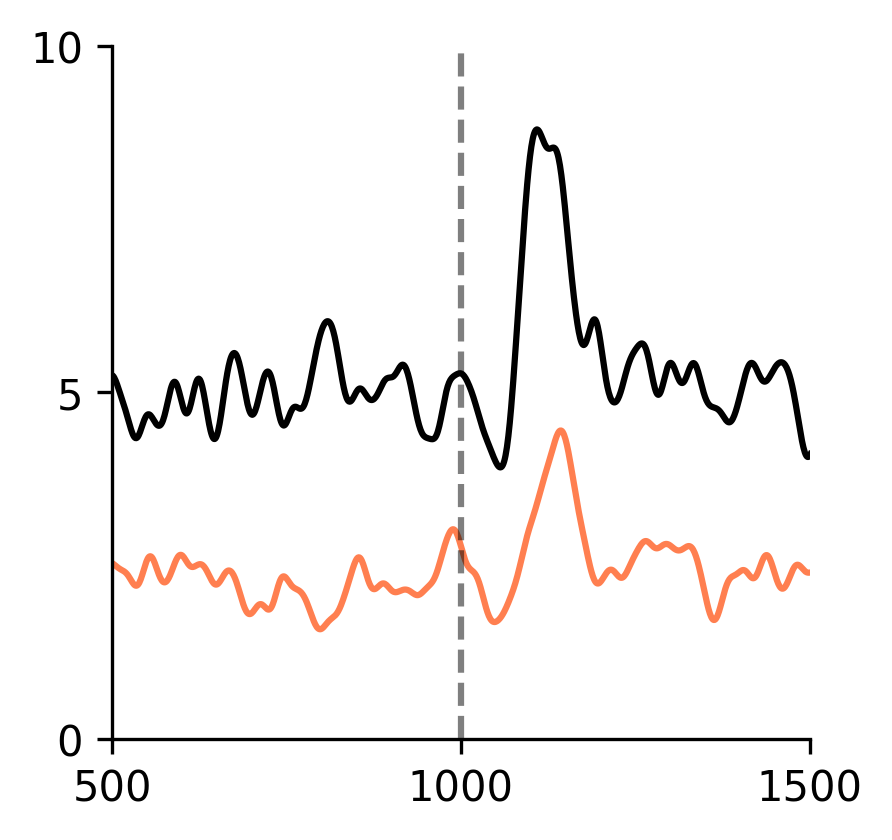

In [75]:
Cell = 498

PreDOI_GazeT= DOI_Data.loc[Cell,'Pre_Pref_Gaze_Times']
PostDOI_GazeT = DOI_Data.loc[Cell,'Post_Pref_Gaze_Times']

PreDOI_SpikeT = DOI_Data.loc[Cell,'Pre_SpikeT']
PostDOI_SpikeT = DOI_Data.loc[Cell,'Post_SpikeT']

PSTH_Pre = calc_PSTH(PreDOI_SpikeT, PreDOI_GazeT, bandwidth=10, resample_size=1, edgedrop=15, win=1000, num_events=None)
PSTH_Post = calc_PSTH(PostDOI_SpikeT, PostDOI_GazeT, bandwidth=10, resample_size=1, edgedrop=15, win=1000, num_events=None)




fig, axs=plt.subplots(1,1,figsize=(3,3), dpi=300)
plt.plot(PSTH_Pre,color = 'black')
plt.plot(PSTH_Post,color = 'coral')
plt.xlim(500,1500)
plt.ylim(0,10)
plt.yticks(ticks = [0,5,10])
plt.xticks(ticks = [500,1000,1500])
plt.axvline(1000,linestyle='--',color = 'black',alpha=.5)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
plt.gca().set_rasterized(True)

fig.savefig(os.path.join(figpath, str(Cell) + '_PSTH.eps'),dpi=300)
#plt.close()

In [21]:
PreDOI_Gaze = np.stack(DOI_Data.loc[:,'Pre_Pref_Gaze'])
PostDOI_Gaze = np.stack(DOI_Data.loc[:,'Post_Pref_Gaze'])

PreSaline_Gaze = np.stack(Saline_Data.loc[:,'Pre_Pref_Gaze'])
PostSaline_Gaze = np.stack(Saline_Data.loc[:,'Post_Pref_Gaze'])

#lightly filtering
kernel_size = 25
kernel = np.ones(kernel_size) / kernel_size

PreDOI_Gaze_filt = PreDOI_Gaze.copy()
PostDOI_Gaze_filt = PostDOI_Gaze.copy()
PreSaline_Gaze_filt = PreSaline_Gaze.copy()
PostSaline_Gaze_filt = PostSaline_Gaze.copy()



for ii in range(0,len(PreDOI_Gaze)):
    PreDOI_Gaze_filt[ii,:] =  np.convolve(PreDOI_Gaze[ii,:], kernel, mode = 'same')
    PostDOI_Gaze_filt[ii,:] = np.convolve(PostDOI_Gaze[ii,:], kernel, mode = 'same')



for ii in range(0,len(PreSaline_Gaze)):
    PreSaline_Gaze_filt[ii,:] =  np.convolve(PreSaline_Gaze[ii,:], kernel, mode = 'same')
    PostSaline_Gaze_filt[ii,:] = np.convolve(PostSaline_Gaze[ii,:], kernel, mode = 'same')


#Normalizing Gaze Shift Responses 
PreDOI_Baseline = np.nanmean(PreDOI_Gaze_filt[:,100:750],axis=1)
PostDOI_Baseline = np.nanmean(PostDOI_Gaze_filt[:,100:750],axis=1)
PreSaline_Baseline = np.nanmean(PreSaline_Gaze_filt[:,100:750],axis=1)
PostSaline_Baseline = np.nanmean(PostSaline_Gaze_filt[:,100:750],axis=1)

PreDOI_Gaze_Baselined = PreDOI_Gaze_filt - PreDOI_Baseline[:,None]
PostDOI_Gaze_Baselined = PostDOI_Gaze_filt - PostDOI_Baseline[:,None]
PreSaline_Gaze_Baselined = PreSaline_Gaze_filt - PreSaline_Baseline[:,None]
PostSaline_Gaze_Baselined = PostSaline_Gaze_filt - PostSaline_Baseline[:,None]

PreDOI_Max = np.nanmax(np.abs(PreDOI_Gaze_Baselined[:,900:1500]),axis=1)
PostDOI_Max = np.nanmax(np.abs(PostDOI_Gaze_Baselined[:,900:1500]),axis=1)
DOI_Max = np.nanmax([PreDOI_Max,PostDOI_Max],axis=0)
PreSaline_Max = np.nanmax(np.abs(PreSaline_Gaze_Baselined[:,900:1500]),axis=1)
PostSaline_Max = np.nanmax(np.abs(PostSaline_Gaze_Baselined[:,900:1500]),axis=1)
Saline_Max = np.nanmax([PreSaline_Max,PostSaline_Max],axis=0)

PreDOI_Gaze_Normalized = PreDOI_Gaze_Baselined/DOI_Max[:,None]
PostDOI_Gaze_Normalized = PostDOI_Gaze_Baselined/DOI_Max[:,None]
PreSaline_Gaze_Normalized = PreSaline_Gaze_Baselined/Saline_Max[:,None]
PostSaline_Gaze_Normalized = PostSaline_Gaze_Baselined/Saline_Max[:,None]

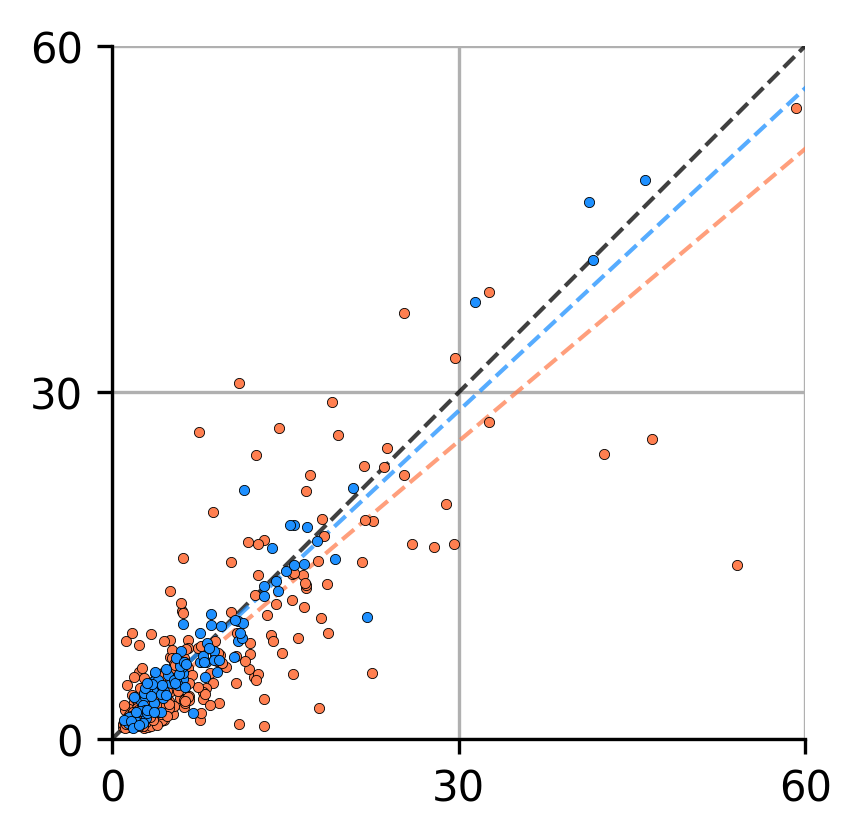

In [22]:
#Making max responses plots
PreDOI_Gaze_Baselined = PreDOI_Gaze_filt - PreDOI_Baseline[:,None]
PostDOI_Gaze_Baselined = PostDOI_Gaze_filt - PostDOI_Baseline[:,None]
PreSaline_Gaze_Baselined = PreSaline_Gaze_filt - PreSaline_Baseline[:,None]
PostSaline_Gaze_Baselined = PostSaline_Gaze_filt - PostSaline_Baseline[:,None]

PreDOI_Max = np.nanmax(np.abs(PreDOI_Gaze_Baselined[:,900:1500]),axis=1)
PostDOI_Max = np.nanmax(np.abs(PostDOI_Gaze_Baselined[:,900:1500]),axis=1)
PostDOI_Max = np.nan_to_num(PostDOI_Max)

PreSaline_Max = np.nanmax(np.abs(PreSaline_Gaze_Baselined[:,900:1500]),axis=1)
PostSaline_Max = np.nanmax(np.abs(PostSaline_Gaze_Baselined[:,900:1500]),axis=1)


DOI_coefficients = np.polyfit(PreDOI_Max[DOI_ResponsivetoBoth.astype(bool)],PostDOI_Max[DOI_ResponsivetoBoth.astype(bool)], 1)
DOI_slope = DOI_coefficients[0]
DOI_intercept = DOI_coefficients[1]
DOI_line_x = np.array([np.nanmin(PreDOI_Max[DOI_ResponsivetoBoth.astype(bool)]), np.nanmax(PreDOI_Max[DOI_ResponsivetoBoth.astype(bool)])])
DOI_line_y = DOI_slope * DOI_line_x + DOI_intercept

#Saline
Saline_coefficients = np.polyfit(PreSaline_Max[Saline_ResponsivetoBoth.astype(bool)],PostSaline_Max[Saline_ResponsivetoBoth.astype(bool)], 1)
Saline_slope = Saline_coefficients[0]
Saline_intercept = Saline_coefficients[1]
Saline_line_x = np.array([np.nanmin(PreSaline_Max[Saline_ResponsivetoBoth.astype(bool)]), np.nanmax(PreSaline_Max[Saline_ResponsivetoBoth.astype(bool)])])
Saline_line_y = Saline_slope * Saline_line_x + Saline_intercept

fig, axs=plt.subplots(1,1,figsize=(3,3), dpi=300)
plt.scatter(PreDOI_Max[DOI_ResponsivetoBoth.astype(bool)],PostDOI_Max[DOI_ResponsivetoBoth.astype(bool)],color = 'coral', s=6,zorder = 7,edgecolor = 'black',linewidth=.2)
plt.scatter(PreSaline_Max[Saline_ResponsivetoBoth.astype(bool)],PostSaline_Max[Saline_ResponsivetoBoth.astype(bool)], color = 'dodgerblue', s=6,zorder = 7,edgecolor = 'black',linewidth=.2)

plt.plot([0,60],[0,60],color ='black',linestyle='--', linewidth=1, alpha=.75,zorder = 6)
plt.xlim([0,60])
plt.ylim([0,60])

plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
plt.gca().set_rasterized(True)
plt.xticks(ticks=[0,30,60])
plt.yticks(ticks=[0,30,60])
plt.gca().set_aspect('equal', 'box')

plt.plot(DOI_line_x, DOI_line_y, color='coral', linewidth=1, alpha=.75,linestyle='--',zorder = 6)
plt.plot(Saline_line_x, Saline_line_y, color='dodgerblue', linewidth=1, alpha=.75,linestyle='--',zorder = 6)
plt.grid(zorder = 3)

#fig.savefig(os.path.join(figpath, 'Pre vs Post Gaze Shifts FR- RTB Neurons.eps'), dpi=300)

In [241]:
DOI_Data_4Mice_Light.columns

Index(['Mouse', 'Cell', 'Pre_Responsive', 'Post_Responsive', 'Pre_Gaze_DS',
       'Post_Gaze_DS', 'Pre_Left_Gaze', 'Pre_Right_Gaze', 'Post_Left_Gaze',
       'Post_Right_Gaze', 'Pre_Pref_Gaze', 'Post_Pref_Gaze',
       'Pre_NonPref_Gaze', 'Post_NonPref_Gaze', 'Pre_Pref_Gaze_Times',
       'Post_Pref_Gaze_Times', 'Pre_NonPref_Gaze_Times',
       'Post_NonPref_Gaze_Times', 'Pre_SpikeT', 'Post_SpikeT',
       'Contamination_Index'],
      dtype='object')

In [23]:
PreDOI_GazeDark = np.stack(DOI_Data_4Mice_Dark.loc[:,'Pre_Pref_Gaze'])
PostDOI_GazeDark = np.stack(DOI_Data_4Mice_Dark.loc[:,'Post_Pref_Gaze'])

#lightly filtering
kernel_size = 25
kernel = np.ones(kernel_size) / kernel_size

PreDOI_GazeDark_filt = PreDOI_GazeDark.copy()
PostDOI_GazeDark_filt = PostDOI_GazeDark.copy()

for ii in range(0,len(PreDOI_GazeDark)):
    PreDOI_GazeDark_filt[ii,:] =  np.convolve(PreDOI_GazeDark[ii,:], kernel, mode = 'same')
    PostDOI_GazeDark_filt[ii,:] = np.convolve(PostDOI_GazeDark[ii,:], kernel, mode = 'same')

#Normalizing Gaze Shift Responses 
PreDOIDark_Baseline = np.nanmean(PreDOI_GazeDark_filt[:,100:750],axis=1)
PostDOIDark_Baseline = np.nanmean(PostDOI_GazeDark_filt[:,100:750],axis=1)

PreDOI_GazeDark_Baselined = PreDOI_GazeDark_filt - PreDOIDark_Baseline[:,None]
PostDOI_GazeDark_Baselined = PostDOI_GazeDark_filt - PostDOIDark_Baseline[:,None]

PreDOIDark_Max = np.nanmax(np.abs(PreDOI_GazeDark_Baselined[:,900:1500]),axis=1)
PostDOIDark_Max = np.nanmax(np.abs(PostDOI_GazeDark_Baselined[:,900:1500]),axis=1)
DarkDOI_Max = np.nanmax([PreDOIDark_Max,PostDOIDark_Max],axis=0)


PreDOI_GazeDark_Normalized = PreDOI_GazeDark_Baselined/DarkDOI_Max[:,None]
PostDOI_GazeDark_Normalized = PostDOI_GazeDark_Baselined/DarkDOI_Max[:,None]

In [24]:
Mice = np.stack(DOI_Data.loc[Pre_DOI_Responsive.astype(bool),'Mouse'])
Mouse = np.unique(Mice)

PreDOI_Max_MouseAvs =  np.zeros(len(Mouse))
PostDOI_Max_MouseAvs =  np.zeros(len(Mouse))
PreDOI_Baseline_MouseAvs =  np.zeros(len(Mouse))
PostDOI_Baseline_MouseAvs =  np.zeros(len(Mouse))
BothDOI_Responsive_MouseAvs =  np.zeros(len(Mouse))
DOI_NumCells =  np.zeros(len(Mouse))

for ii in range(0,len(Mouse)):
    Mouse_Idxes = np.argwhere(Mice == Mouse[ii])
    DOI_NumCells[ii] = len(Mouse_Idxes)
    PreDOI_Max_MouseAvs[ii] = np.nanmean(PreDOI_Max[Mouse_Idxes])
    PostDOI_Max_MouseAvs[ii] = np.nanmean(PostDOI_Max[Mouse_Idxes])
    PreDOI_Baseline_MouseAvs[ii] = np.nanmean(PreDOI_Baseline[Mouse_Idxes])
    PostDOI_Baseline_MouseAvs[ii] = np.nanmean(PostDOI_Baseline[Mouse_Idxes])

    

In [25]:
Mice = np.stack(Saline_Data.loc[Pre_Saline_Responsive.astype(bool),'Mouse'])
Mouse = np.unique(Mice)

PreSaline_Max_MouseAvs =  np.zeros(len(Mouse))
PostSaline_Max_MouseAvs =  np.zeros(len(Mouse))
PreSaline_Baseline_MouseAvs =  np.zeros(len(Mouse))
PostSaline_Baseline_MouseAvs =  np.zeros(len(Mouse))
BothSaline_Responsive_MouseAvs =  np.zeros(len(Mouse))
Saline_NumCells =  np.zeros(len(Mouse))

for ii in range(0,len(Mouse)):
    Mouse_Idxes = np.argwhere(Mice == Mouse[ii])
    Saline_NumCells[ii] = len(Mouse_Idxes)
    PreSaline_Max_MouseAvs[ii] = np.nanmean(PreSaline_Max[Mouse_Idxes])
    PostSaline_Max_MouseAvs[ii] = np.nanmean(PostSaline_Max[Mouse_Idxes])
    PreSaline_Baseline_MouseAvs[ii] = np.nanmean(PreSaline_Baseline[Mouse_Idxes])
    PostSaline_Baseline_MouseAvs[ii] = np.nanmean(PostSaline_Baseline[Mouse_Idxes])


In [26]:
Pre_DOIDark_Responsive = np.stack(DOI_Data_4Mice_Light.loc[:,'Pre_Responsive'])
Mice = np.stack(DOI_Data_4Mice_Dark.loc[Pre_DOIDark_Responsive.astype(bool),'Mouse'])
Mice = np.stack(DOI_Data_4Mice_Dark.loc[:,'Mouse'])
Mouse = np.unique(Mice)

PreDOIDark_Max_MouseAvs =  np.zeros(len(Mouse))
PostDOIDark_Max_MouseAvs =  np.zeros(len(Mouse))
PreDOIDark_Baseline_MouseAvs =  np.zeros(len(Mouse))
PostDOIDark_Baseline_MouseAvs =  np.zeros(len(Mouse))
DOIDark_NumCells =  np.zeros(len(Mouse))

for ii in range(0,len(Mouse)):
    Mouse_Idxes = np.argwhere(Mice == Mouse[ii])
    DOIDark_NumCells[ii] = len(Mouse_Idxes)
    PreDOIDark_Max_MouseAvs[ii] = np.nanmean(PreDOIDark_Max[Mouse_Idxes])
    PostDOIDark_Max_MouseAvs[ii] = np.nanmean(PostDOIDark_Max[Mouse_Idxes])
    PreDOIDark_Baseline_MouseAvs[ii] = np.nanmean(PreDOIDark_Baseline[Mouse_Idxes])
    PostDOIDark_Baseline_MouseAvs[ii] = np.nanmean(PostDOIDark_Baseline[Mouse_Idxes])


In [27]:
darkfigpath = r'G:\My Drive\Science Files\Manuscripts\DOI Project\Figures\Fig 7 - Dark Recordings'

Pre_Dark_Baseline = np.load(os.path.join(darkfigpath, 'PreDarkBaseline.npy'))
Post_Dark_Baseline = np.load(os.path.join(darkfigpath, 'PostDarkBaseline.npy'))
Pre_Light_Baseline = np.load(os.path.join(darkfigpath, 'PreLightBaseline.npy'))
Post_Light_Baseline = np.load(os.path.join(darkfigpath, 'PostLightBaseline.npy'))

Pre_Dark_Max = np.load(os.path.join(darkfigpath, 'PreDarkMax.npy'))
Post_Dark_Max = np.load(os.path.join(darkfigpath, 'PostDarkMax.npy'))
Pre_Light_Max = np.load(os.path.join(darkfigpath, 'PreLightMax.npy'))
Post_Light_Max = np.load(os.path.join(darkfigpath, 'PostLightMax.npy'))


In [273]:
PreDOIDark_Max_MouseAvs

array([9.19979273, 5.24155716, 7.77425211, 8.76948686])

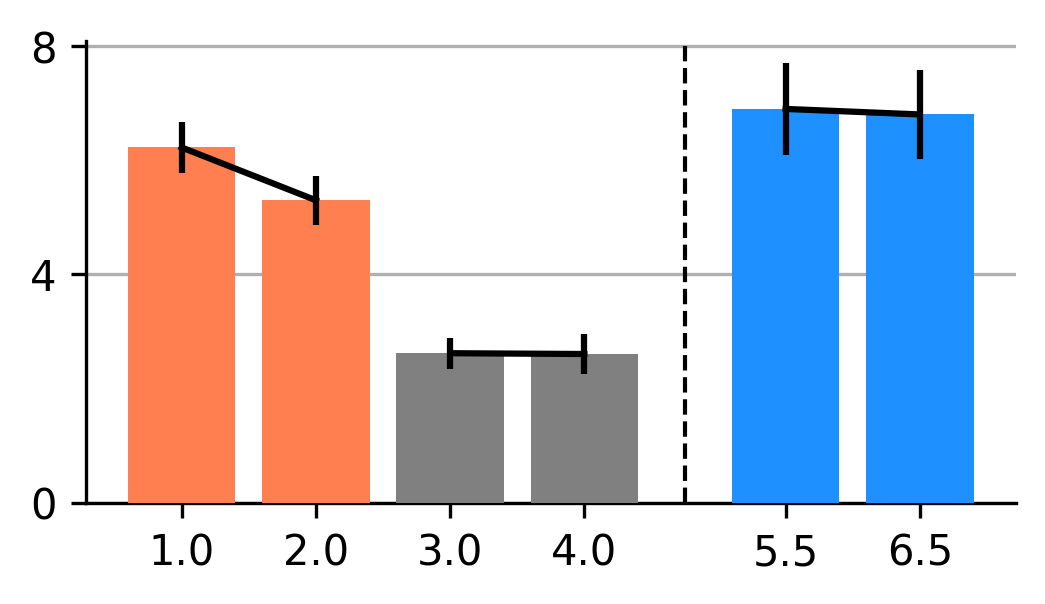

In [32]:
fig, axs=plt.subplots(1,1,figsize=(4,2), dpi=300)
plt.bar(1,np.nanmean(PreDOI_Max),color = 'coral',zorder = 5)
plt.bar(2,np.nanmean(PostDOI_Max),color = 'coral',zorder = 5)
plt.bar(3,np.nanmean(Pre_Dark_Max),color = 'grey',zorder = 5)
plt.bar(4,np.nanmean(Post_Dark_Max),color = 'grey',zorder = 5)
plt.bar(5.5,np.nanmean(PreSaline_Max),color = 'dodgerblue',zorder = 5)
plt.bar(6.5,np.nanmean(PostSaline_Max),color = 'dodgerblue',zorder = 5)

plt.errorbar(1,np.nanmean(PreDOI_Max),np.nanstd(PreDOI_Max)/sqrt(len(PreDOI_Max)),color = 'black',zorder = 6)
plt.errorbar(2,np.nanmean(PostDOI_Max),np.nanstd(PostDOI_Max)/sqrt(len(PostDOI_Max)),color = 'black',zorder = 6)
plt.errorbar(3,np.nanmean(Pre_Dark_Max),np.nanstd(Pre_Dark_Max)/sqrt(len(Pre_Dark_Max)),color = 'black',zorder = 6)
plt.errorbar(4,np.nanmean(Post_Dark_Max),np.nanstd(Post_Dark_Max)/sqrt(len(Post_Dark_Max)),color = 'black',zorder = 6)
plt.errorbar(5.5,np.nanmean(PreSaline_Max),np.nanstd(PreSaline_Max)/sqrt(len(PreSaline_Max)),color = 'black',zorder = 6)
plt.errorbar(6.5,np.nanmean(PostSaline_Max),np.nanstd(PostSaline_Max)/sqrt(len(PostSaline_Max)),color = 'black',zorder = 6)

plt.plot([1,2],[np.nanmean(PreDOI_Max),np.nanmean(PostDOI_Max)],color = 'black',zorder = 6)
plt.plot([3,4],[np.nanmean(Pre_Dark_Max),np.nanmean(Post_Dark_Max)],color = 'black',zorder = 6)
plt.plot([5.5,6.5],[np.nanmean(PreSaline_Max),np.nanmean(PostSaline_Max)],color = 'black',zorder = 6)


plt.axvline(4.75,color = 'black',linestyle='--',linewidth=1)
plt.yticks(ticks = [0,4,8])
plt.xticks(ticks=[1,2,3,4,5.5,6.5])
plt.grid(axis = 'y',zorder = 3)

plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

#fig.savefig(os.path.join(figpath, 'Mean_GazeShiftEvokedFR_PrePost_Light_Dark.eps'), dpi=300)

In [37]:
import scipy.interpolate
import scipy.signal

print(scipy.stats.ranksums(np.nan_to_num(PreDOI_Max),np.nan_to_num(PostDOI_Max),alternative= 'greater'))
print(scipy.stats.ranksums(np.nan_to_num(Pre_Dark_Max),np.nan_to_num(Post_Dark_Max),alternative= 'greater'))
print(scipy.stats.ranksums(np.nan_to_num(PreSaline_Max),np.nan_to_num(PostSaline_Max),alternative= 'greater'))

RanksumsResult(statistic=3.943295993142876, pvalue=4.0184680346713035e-05)
RanksumsResult(statistic=1.3949317371733325, pvalue=0.08151821275963128)
RanksumsResult(statistic=0.0353121394550534, pvalue=0.48591542174164754)


In [31]:
np.shape(PreDOI_Max)

(418,)

In [49]:
np.nanmean(PreDOI_Baseline)

9.158654971796945

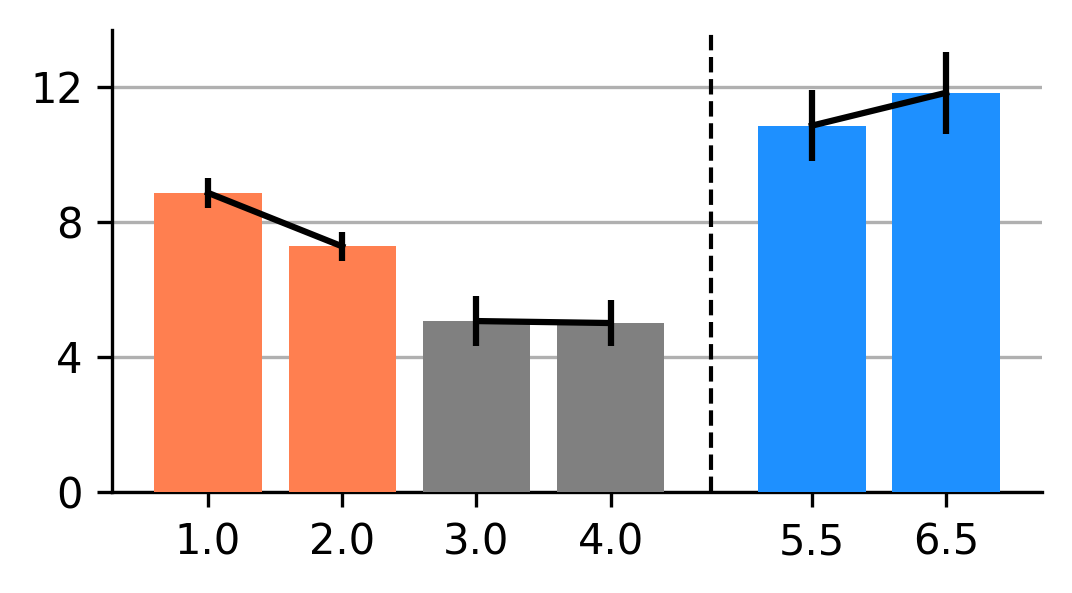

In [210]:
fig, axs=plt.subplots(1,1,figsize=(4,2), dpi=300)
plt.bar(1,np.nanmean(PreDOI_Baseline),color = 'coral',zorder = 5)
plt.bar(2,np.nanmean(PostDOI_Baseline),color = 'coral',zorder = 5)
plt.bar(3,np.nanmean(Pre_Dark_Baseline),color = 'grey',zorder = 5)
plt.bar(4,np.nanmean(Post_Dark_Baseline),color = 'grey',zorder = 5)
plt.bar(5.5,np.nanmean(PreSaline_Baseline),color = 'dodgerblue',zorder = 5)
plt.bar(6.5,np.nanmean(PostSaline_Baseline),color = 'dodgerblue',zorder = 5)

plt.errorbar(1,np.nanmean(PreDOI_Baseline),np.nanstd(PreDOI_Baseline)/sqrt(len(PreDOI_Baseline)),color = 'black',zorder = 6)
plt.errorbar(2,np.nanmean(PostDOI_Baseline),np.nanstd(PostDOI_Baseline)/sqrt(len(PostDOI_Baseline)),color = 'black',zorder = 6)
plt.errorbar(3,np.nanmean(Pre_Dark_Baseline),np.nanstd(Pre_Dark_Baseline)/sqrt(len(Pre_Dark_Baseline)),color = 'black',zorder = 6)
plt.errorbar(4,np.nanmean(Post_Dark_Baseline),np.nanstd(Post_Dark_Baseline)/sqrt(len(Post_Dark_Baseline)),color = 'black',zorder = 6)
plt.errorbar(5.5,np.nanmean(PreSaline_Baseline),np.nanstd(PreSaline_Baseline)/sqrt(len(PreSaline_Baseline)),color = 'black',zorder = 6)
plt.errorbar(6.5,np.nanmean(PostSaline_Baseline),np.nanstd(PostSaline_Baseline)/sqrt(len(PostSaline_Baseline)),color = 'black',zorder = 6)

plt.plot([1,2],[np.nanmean(PreDOI_Baseline),np.nanmean(PostDOI_Baseline)],color = 'black',zorder = 6)
plt.plot([3,4],[np.nanmean(Pre_Dark_Baseline),np.nanmean(Post_Dark_Baseline)],color = 'black',zorder = 6)
plt.plot([5.5,6.5],[np.nanmean(PreSaline_Baseline),np.nanmean(PostSaline_Baseline)],color = 'black',zorder = 6)

plt.axvline(4.75,color = 'black',linestyle='--',linewidth=1)
plt.yticks(ticks = [0,4,8,12])
plt.xticks(ticks=[1,2,3,4,5.5,6.5])
plt.grid(axis = 'y',zorder = 3)

plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)


#fig.savefig(os.path.join(figpath, 'Mean_BaselineFR_PrePost_Light_Dark.eps'), dpi=300)

In [58]:
import scipy.interpolate
import scipy.signal

print('Pre DOI')
print(np.nanmean(PreDOI_Max))
print(np.nanstd(PreDOI_Max)/sqrt(len(PreDOI_Max)))
print('Post DOI')
print(np.nanmean(PostDOI_Max))
print(np.nanstd(PostDOI_Max)/sqrt(len(PostDOI_Max)))
print(scipy.stats.ranksums(np.nan_to_num(PreDOI_Max),np.nan_to_num(PostDOI_Max),alternative= 'greater'))

print('Pre Saline')
print(np.nanmean(PreSaline_Max))
print(np.nanstd(PreSaline_Max)/sqrt(len(PreSaline_Max)))
print('Pre Saline')
print(np.nanmean(PostSaline_Max))
print(np.nanstd(PostSaline_Max)/sqrt(len(PostSaline_Max)))
print(scipy.stats.ranksums(np.nan_to_num(PreSaline_Max),np.nan_to_num(PostSaline_Max),alternative= 'greater'))


print('Dark')
print(scipy.stats.ranksums(np.nan_to_num(Pre_Dark_Max),np.nan_to_num(Post_Dark_Max),alternative= 'greater'))

Pre DOI
6.224417989841593
0.44229962529741645
Post DOI
5.299677066283966
0.43360677460567815
RanksumsResult(statistic=3.943295993142876, pvalue=4.0184680346713035e-05)
Pre Saline
6.900057104356918
0.8073796606627847
Pre Saline
6.80322936934671
0.7740966132081463
RanksumsResult(statistic=0.0353121394550534, pvalue=0.48591542174164754)
Dark
RanksumsResult(statistic=1.3949317371733325, pvalue=0.08151821275963128)


In [59]:
import scipy.interpolate
import scipy.signal

print('Pre DOI')
print(np.nanmean(PreDOI_Baseline))
print(np.nanstd(PreDOI_Baseline)/sqrt(len(PreDOI_Baseline)))
print('Post DOI')
print(np.nanmean(PostDOI_Baseline))
print(np.nanstd(PostDOI_Baseline)/sqrt(len(PostDOI_Baseline)))
print(scipy.stats.ranksums(np.nan_to_num(PreDOI_Baseline),np.nan_to_num(PostDOI_Baseline),alternative= 'greater'))

print('Pre Saline')
print(np.nanmean(PreSaline_Baseline))
print(np.nanstd(PreSaline_Baseline)/sqrt(len(PreSaline_Baseline)))
print('Pre Saline')
print(np.nanmean(PostSaline_Baseline))
print(np.nanstd(PostSaline_Baseline)/sqrt(len(PostSaline_Baseline)))
print(scipy.stats.ranksums(np.nan_to_num(PreSaline_Baseline),np.nan_to_num(PostSaline_Baseline),alternative= 'greater'))

print('Dark')
print(scipy.stats.ranksums(np.nan_to_num(Pre_Dark_Baseline),np.nan_to_num(Post_Dark_Baseline),alternative= 'greater'))


Pre DOI
9.158654971796945
0.5447567334067138
Post DOI
6.841280384787631
0.43083113237891785
RanksumsResult(statistic=4.350344054036093, pvalue=6.7962046661471e-06)
Pre Saline
10.845135187505974
1.0442306650861888
Pre Saline
11.81929169378887
1.2121424985089562
RanksumsResult(statistic=-0.347688757711295, pvalue=0.6359630297124041)
Dark
RanksumsResult(statistic=0.20332903287611287, pvalue=0.41943893225533047)


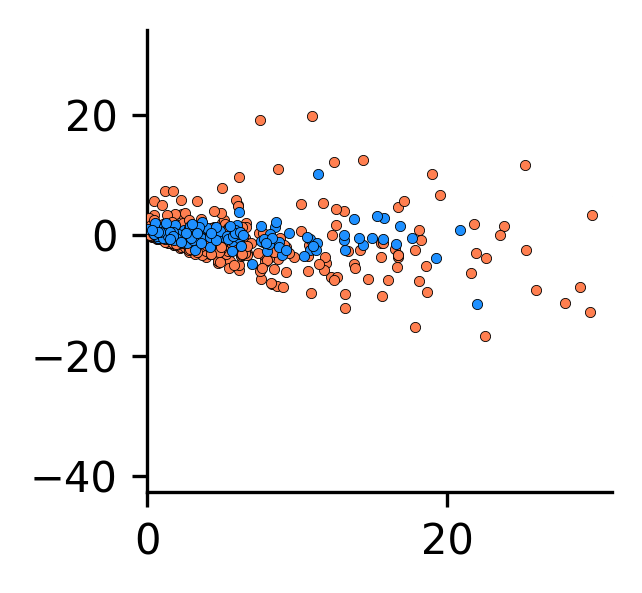

In [35]:
fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)
plt.scatter(PreDOI_Max,DOI_ChangeFR,color = 'coral', s=6,zorder = 7,edgecolor = 'black',linewidth=.2)
plt.scatter(PreSaline_Max,Saline_ChangeFR, color = 'dodgerblue', s=6,zorder = 7,edgecolor = 'black',linewidth=.2)



#plt.plot([0,60],[0,60],color ='black',linestyle='--', linewidth=1, alpha=.75,zorder = 6)
plt.xlim([0,31])
#plt.ylim([0,31])

plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
plt.gca().set_rasterized(True)
#plt.xticks(ticks=[0,30,60])
#plt.yticks(ticks=[0,30,60])
#plt.gca().set_aspect('equal', 'box')


In [29]:
#Making baseline change plots

DOI_coefficients = np.polyfit(PreDOI_Baseline[Pre_DOI_Responsive.astype(bool)],PostDOI_Baseline[Pre_DOI_Responsive.astype(bool)], 1)
DOI_slope = DOI_coefficients[0]
DOI_intercept = DOI_coefficients[1]

DOI_line_x = np.array([np.nanmin(PreDOI_Baseline[Pre_DOI_Responsive.astype(bool)]), np.nanmax(PreDOI_Baseline[Pre_DOI_Responsive.astype(bool)])])
DOI_line_y = DOI_slope * DOI_line_x + DOI_intercept

#Saline

Saline_coefficients = np.polyfit(PreSaline_Baseline[Pre_Saline_Responsive.astype(bool)],PostSaline_Baseline[Pre_Saline_Responsive.astype(bool)], 1)
Saline_slope = Saline_coefficients[0]
Saline_intercept = Saline_coefficients[1]

Saline_line_x = np.array([np.nanmin(PreSaline_Baseline[Pre_Saline_Responsive.astype(bool)]), np.nanmax(PreSaline_Baseline[Pre_Saline_Responsive.astype(bool)])])
Saline_line_y = Saline_slope * Saline_line_x + Saline_intercept

fig, axs=plt.subplots(1,1,figsize=(3,3), dpi=300)
plt.scatter(PreDOI_Baseline[Pre_DOI_Responsive.astype(bool)],PostDOI_Baseline[Pre_DOI_Responsive.astype(bool)],color = 'coral', s=6,zorder = 7,edgecolor = 'black',linewidth=.2)
plt.scatter(PreSaline_Baseline[Pre_Saline_Responsive.astype(bool)],PostSaline_Baseline[Pre_Saline_Responsive.astype(bool)], color = 'dodgerblue', s=6,zorder = 7,edgecolor = 'black',linewidth=.2)

plt.plot([0,60],[0,60],color ='black',linestyle='--', linewidth=1, alpha=.75,zorder = 6)
plt.xlim([0,61])
plt.ylim([0,61])

plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
plt.gca().set_rasterized(True)
plt.xticks(ticks=[0,30,60])
plt.yticks(ticks=[0,30,60])
plt.gca().set_aspect('equal', 'box')


plt.plot(DOI_line_x, DOI_line_y, color='coral', linewidth=1, alpha=.75,linestyle='--',zorder = 6)
plt.plot(Saline_line_x, Saline_line_y, color='dodgerblue', linewidth=1, alpha=.75,linestyle='--',zorder = 6)
plt.grid(zorder = 3)


#fig.savefig(os.path.join(figpath, 'Pre vs Post Gaze Shifts Baseline FR- RTB Neurons.eps'), dpi=300)

LinAlgError: SVD did not converge in Linear Least Squares

In [61]:
plt.scatter(DOI_ChangeFR,DOI_BaselineChange)

NameError: name 'DOI_ChangeFR' is not defined

In [30]:
Mice = np.stack(DOI_Data.loc[Pre_DOI_Responsive.astype(bool),'Mouse'])
Mouse = np.unique(Mice)

DOI_ChangeFR = PostDOI_Max - PreDOI_Max
Saline_ChangeFR = PostSaline_Max- PreSaline_Max

DOI_BaselineChange = PostDOI_Baseline - PreDOI_Baseline
Saline_BaselineChange = PostSaline_Baseline - PreSaline_Baseline


DOI_ChangeFR_MouseAvs =  np.zeros(len(Mouse))
DOI_ChangeBaseline_MouseAvs =  np.zeros(len(Mouse))
DOI_NumCells =  np.zeros(len(Mouse))
for ii in range(0,len(Mouse)):
    Mouse_Idxes = np.argwhere(Mice == Mouse[ii])
    DOI_ChangeFR_MouseAvs[ii] = np.nanmean(DOI_ChangeFR[Mouse_Idxes])
    DOI_NumCells[ii] = len(Mouse_Idxes)
    DOI_ChangeBaseline_MouseAvs[ii] = np.nanmean(DOI_BaselineChange[Mouse_Idxes])
    
Saline_Mice = np.stack(Saline_Data.loc[Pre_Saline_Responsive.astype(bool),'Mouse'])
Saline_Mouse = np.unique(Saline_Mice)

Saline_ChangeFR_MouseAvs =  np.zeros(len(Saline_Mouse))
Saline_ChangeBaseline_MouseAvs =  np.zeros(len(Saline_Mouse))
Saline_NumCells =  np.zeros(len(Mouse))
for ii in range(0,len(Saline_Mouse)):
    Saline_Mouse_Idxes = np.argwhere(Saline_Mice == Saline_Mouse[ii])
    Saline_ChangeFR_MouseAvs[ii] = np.nanmean(Saline_ChangeFR[Saline_Mouse_Idxes])
    Saline_NumCells[ii] = len(Saline_Mouse_Idxes)
    Saline_ChangeBaseline_MouseAvs[ii] = np.nanmean(Saline_BaselineChange[Saline_Mouse_Idxes])

DOI_NumCell_Ratio = DOI_NumCells/np.nansum(DOI_NumCells)
Saline_NumCell_Ratio = Saline_NumCells/np.nansum(Saline_NumCells)


ValueError: unequal length arrays

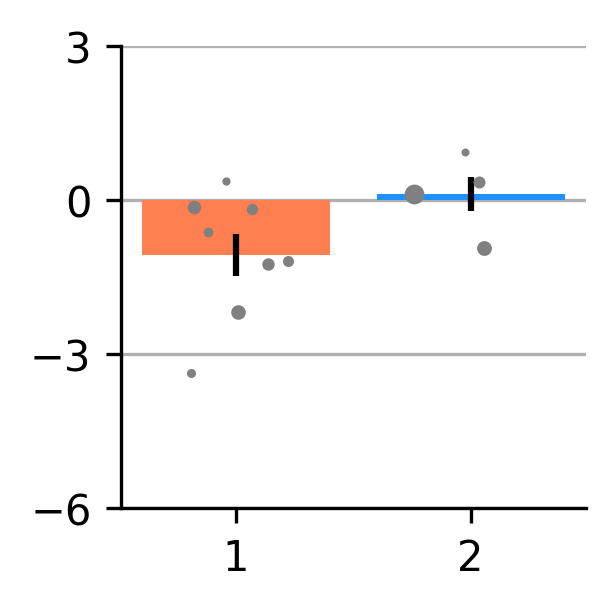

In [33]:
fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)

plt.bar(1,np.nanmean(DOI_ChangeFR_MouseAvs),color = 'coral',zorder = 5)
plt.bar(2,np.nanmean(Saline_ChangeFR_MouseAvs),color = 'dodgerblue',zorder = 5)

plt.errorbar(1,np.nanmean(DOI_ChangeFR_MouseAvs),np.nanstd(DOI_ChangeFR_MouseAvs)/sqrt(len(DOI_ChangeFR_MouseAvs)),color = 'black',zorder = 6)
plt.errorbar(2,np.nanmean(Saline_ChangeFR_MouseAvs),np.nanstd(Saline_ChangeFR_MouseAvs)/sqrt(len(Saline_ChangeFR_MouseAvs)),color = 'black',zorder = 6)

for ii in range(0,8):
    plt.scatter(jitter(0,1),DOI_ChangeFR_MouseAvs[ii],color = 'grey',zorder = 6,s=25*DOI_NumCell_Ratio[ii])
for ii in range(0,4):
    plt.scatter(jitter(1,1),Saline_ChangeFR_MouseAvs[ii],color = 'grey',zorder = 6,s=25*Saline_NumCell_Ratio[ii])

plt.yticks(ticks = [-6,-3,0,3])
plt.xticks(ticks=[1,2])
plt.grid(axis = 'y',zorder = 3)

plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

#fig.savefig(os.path.join(figpath, 'Change in Evoked FR-MouseAverages- RTB Neurons.eps'), dpi=300)

t_stat, p_value = stats.ttest_rel(DOI_ChangeFR_MouseAvs,Saline_ChangeFR_MouseAvs,alternative='less')
print(t_stat)
print(p_value)

-2.1071102163966002
0.01777446738703789


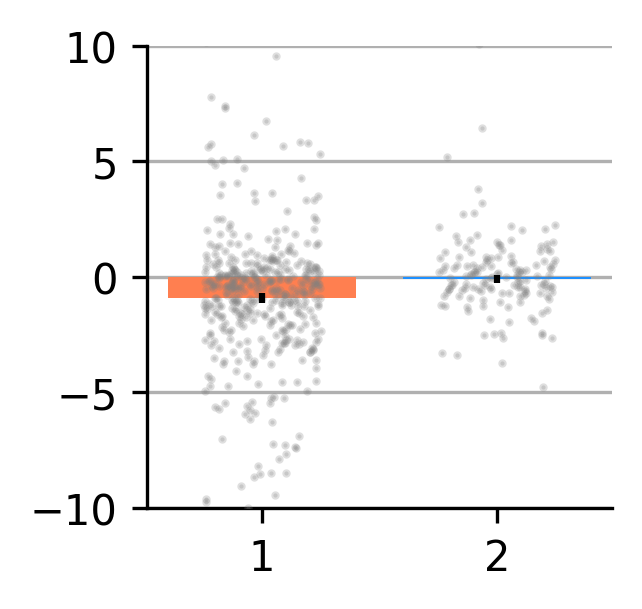

In [34]:
fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)

plt.bar(1,np.nanmean(DOI_ChangeFR),color = 'coral',zorder = 3)
plt.bar(2,np.nanmean(Saline_ChangeFR),color = 'dodgerblue',zorder = 3)

plt.scatter(jitter(0,len(DOI_ChangeFR)),DOI_ChangeFR,zorder =5 ,s=1,color ='grey',alpha=.25)
plt.scatter(jitter(1,len(Saline_ChangeFR)),Saline_ChangeFR,zorder =5 ,s=1,color ='grey',alpha=.25)

plt.errorbar(1,np.nanmean(DOI_ChangeFR),np.nanstd(DOI_ChangeFR)/sqrt(len(DOI_ChangeFR)),color = 'black',zorder = 6)
plt.errorbar(2,np.nanmean(Saline_ChangeFR),np.nanstd(Saline_ChangeFR)/sqrt(len(Saline_ChangeFR)),color = 'black',zorder = 6)

plt.ylim(-10,10)

plt.yticks(ticks = [-10,-5,0,5,10])
plt.xticks(ticks=[1,2])
plt.grid(axis = 'y',zorder = 3)

plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
plt.gca().set_rasterized(True)
#fig.savefig(os.path.join(figpath, 'Change in Evoked FR- RTB Neurons.eps'), dpi=300)

t_stat, p_value = stats.ttest_ind(DOI_ChangeFR,Saline_ChangeFR,alternative='less')
print(t_stat)
print(p_value)

-6.375006653680219
1.918644041989614e-10


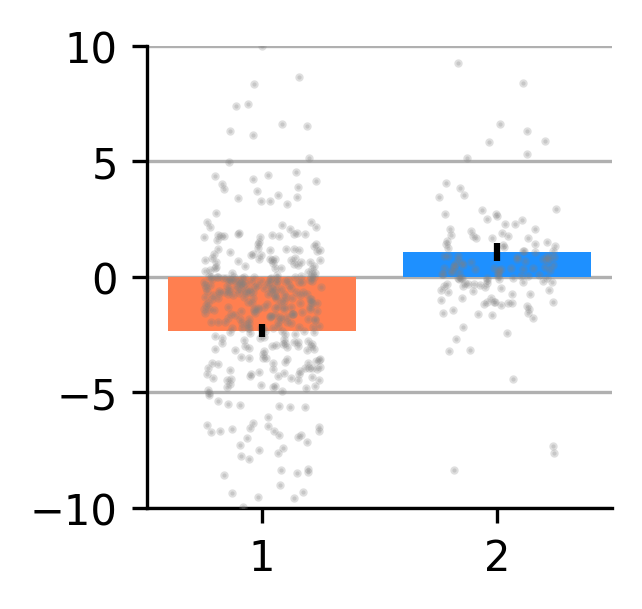

In [59]:
fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)

DOI_BaselineChange[np.where(np.isnan(DOI_BaselineChange)== 1)] = 0

plt.bar(1,np.nanmean(DOI_BaselineChange),color = 'coral',zorder = 3)
plt.bar(2,np.nanmean(Saline_BaselineChange),color = 'dodgerblue',zorder = 3)

plt.scatter(jitter(0,len(DOI_BaselineChange)),DOI_BaselineChange,zorder =5 ,s=1,color ='grey',alpha=.25)
plt.scatter(jitter(1,len(Saline_BaselineChange)),Saline_BaselineChange,zorder =5 ,s=1,color ='grey',alpha=.25)

plt.errorbar(1,np.nanmean(DOI_BaselineChange),np.nanstd(DOI_BaselineChange)/sqrt(len(DOI_BaselineChange)),color = 'black',zorder = 6)
plt.errorbar(2,np.nanmean(Saline_BaselineChange),np.nanstd(Saline_BaselineChange)/sqrt(len(Saline_BaselineChange)),color = 'black',zorder = 6)

plt.ylim(-10,10)

plt.yticks(ticks = [-10,-5,0,5,10])
plt.xticks(ticks=[1,2])
plt.grid(axis = 'y',zorder = 3)

plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
plt.gca().set_rasterized(True)
fig.savefig(os.path.join(figpath, 'Change in Baseline- RTB Neurons.eps'), dpi=300)


DOI_BaselineChange[np.where(np.isnan(DOI_BaselineChange)== 1)] = 0
t_stat, p_value = stats.ttest_ind(DOI_BaselineChange,Saline_BaselineChange,alternative='less')
print(t_stat)
print(p_value)

-2.9339476132048867
0.007469736062657523


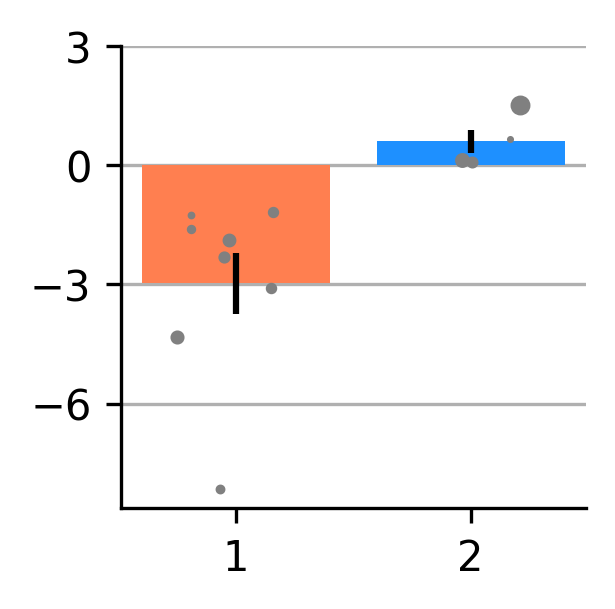

In [134]:
fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)

plt.bar(1,np.nanmean(DOI_ChangeBaseline_MouseAvs),color = 'coral',zorder = 5)
plt.bar(2,np.nanmean(Saline_ChangeBaseline_MouseAvs),color = 'dodgerblue',zorder = 5)

plt.errorbar(1,np.nanmean(DOI_ChangeBaseline_MouseAvs),np.nanstd(DOI_ChangeBaseline_MouseAvs)/sqrt(len(DOI_ChangeBaseline_MouseAvs)),color = 'black',zorder = 6)
plt.errorbar(2,np.nanmean(Saline_ChangeBaseline_MouseAvs),np.nanstd(Saline_ChangeBaseline_MouseAvs)/sqrt(len(Saline_ChangeBaseline_MouseAvs)),color = 'black',zorder = 6)

for ii in range(0,8):
    plt.scatter(jitter(0,1),DOI_ChangeBaseline_MouseAvs[ii],color = 'grey',zorder = 6,s=25*DOI_NumCell_Ratio[ii])
for ii in range(0,4):
    plt.scatter(jitter(1,1),Saline_ChangeBaseline_MouseAvs[ii],color = 'grey',zorder = 6,s=25*Saline_NumCell_Ratio[ii])

plt.yticks(ticks = [-6,-3,0,3])
plt.xticks(ticks=[1,2])
plt.grid(axis = 'y',zorder = 3)

plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

fig.savefig(os.path.join(figpath, 'Change in Baseline FR-MouseAverages- RTB Neurons.eps'), dpi=300)

t_stat, p_value = stats.ttest_ind(DOI_ChangeBaseline_MouseAvs,Saline_ChangeBaseline_MouseAvs,alternative='less')
print(t_stat)
print(p_value)

In [135]:
figpath

'G:\\My Drive\\Science Files\\Manuscripts\\DOI Project\\Figures\\Fig 2\\Example Cells'

In [62]:

DOI_ChangeFR = PostDOI_Max - PreDOI_Max
Saline_ChangeFR = PostSaline_Max- PreSaline_Max

DOI_BaselineChange = PostDOI_Baseline - PreDOI_Baseline
Saline_BaselineChange = PostSaline_Baseline - PreSaline_Baseline



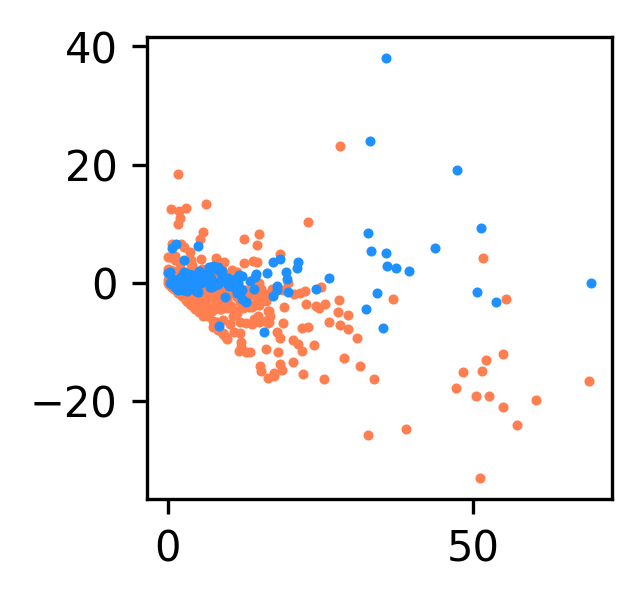

In [73]:
fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)
plt.scatter(PreDOI_Baseline,DOI_BaselineChange,color = 'coral',s=2)
plt.scatter(PreSaline_Baseline,Saline_BaselineChange,color = 'dodgerblue',s=2)